# Phân tích các tham số thống kê 

Dữ liệu sau chuẩn hóa gồm 87 cột, trong đó có 30 cột là các biến định lượng (trong đó có cả các cột category nhưng dạng có thứ tự), 55 cột one-hot encoded, 2 cột cyclic (sin và cos cho 1 biến mùa vụ), và 1 cột nhị phân.



In [1]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "processed_data"

DATA_PATH = DATA_DIR / "encoded_ai_company_adoption.csv"

Y_NAME = "cost_reduction_percent"
# Y_NAME = "customer_satisfaction"

META_PATH = DATA_DIR / "meta_data.json"

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import json

from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD

from prince import FAMD

In [3]:
df = pd.read_csv(DATA_PATH)
df.head(5)

,survey_year,company_size,num_employees,annual_revenue_usd_millions,company_age,ai_adoption_rate,ai_adoption_stage,years_using_ai,num_ai_tools_used,ai_projects_active,...,ai_primary_tool_Other,ai_use_case_Fraud Detection,ai_use_case_HR Automation,ai_use_case_Marketing Automation,ai_use_case_Medical Diagnostics,ai_use_case_Predictive Maintenance,ai_use_case_Software Development,ai_use_case_Supply Chain Optimization,cost_reduction_percent,customer_satisfaction
0,2023,0,57,48.31,29,30.57,1,3,1,3,...,0,0,0,0,0,0,0,0,9.45,5.20
1,2023,0,57,48.31,29,27.25,1,4,3,0,...,0,0,0,0,0,0,1,0,0.00,6.98
2,2023,0,57,48.31,29,31.54,1,2,3,3,...,0,0,1,0,0,0,0,0,9.74,4.12
3,2023,0,57,48.31,29,11.02,1,2,1,2,...,0,0,0,0,0,0,1,0,0.00,5.72
4,2024,0,57,48.31,30,33.39,1,7,3,5,...,0,0,0,0,0,0,0,0,9.02,6.31


In [4]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta_data = json.load(f)
    
    NUMERIC_ORDINAL_COLS = meta_data["numeric_ordinal_cols"]
    ONEHOT_COLS = meta_data["onehot_cols"]
    CYCLIC_COLS = meta_data["cyclic_cols"]
    BINARY_COLS = meta_data["binary_cols"]

### Corvariance Analysis

In [5]:
df[NUMERIC_ORDINAL_COLS].describe()

,survey_year,company_size,num_employees,annual_revenue_usd_millions,company_age,ai_adoption_rate,ai_adoption_stage,years_using_ai,num_ai_tools_used,ai_projects_active,...,task_automation_rate,time_saved_per_week,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,...,150000.000000,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,2024.500987,0.818420,2342.376580,1180.345751,18.507220,36.414726,1.513147,4.931580,2.315120,6.270693,...,19.761744,6.267406,9.266996,111.36984,117.882507,181.642700,4.606486,4.814909,55.199920,5.420619
std,1.118013,0.735699,4754.424755,2391.471420,9.539367,14.544096,0.584468,2.429316,0.946826,3.500142,...,9.222562,2.977495,5.637067,255.83778,261.650245,417.929587,5.318773,3.383086,8.593423,1.047142
min,2023.000000,0.000000,10.000000,1.010000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-5.000000,0.000000,40.000000,1.000000
25%,2024.000000,0.000000,69.000000,33.880000,10.000000,26.430000,1.000000,3.000000,2.000000,4.000000,...,13.360000,4.180000,5.070000,2.00000,3.000000,3.000000,0.780000,2.120000,49.000000,4.700000
50%,2025.000000,1.000000,349.000000,184.160000,18.000000,36.320000,2.000000,5.000000,2.000000,6.000000,...,19.700000,6.230000,9.060000,10.00000,12.000000,16.000000,4.480000,4.620000,55.000000,5.410000
75%,2026.000000,1.000000,884.000000,444.150000,27.000000,46.200000,2.000000,7.000000,3.000000,9.000000,...,26.020000,8.290000,13.120000,41.00000,41.000000,64.000000,8.240000,7.130000,61.000000,6.130000
max,2026.000000,2.000000,19970.000000,9996.730000,36.000000,100.000000,3.000000,10.000000,6.000000,20.000000,...,59.630000,19.150000,34.360000,2417.00000,1980.000000,3881.000000,30.000000,20.790000,97.000000,9.760000


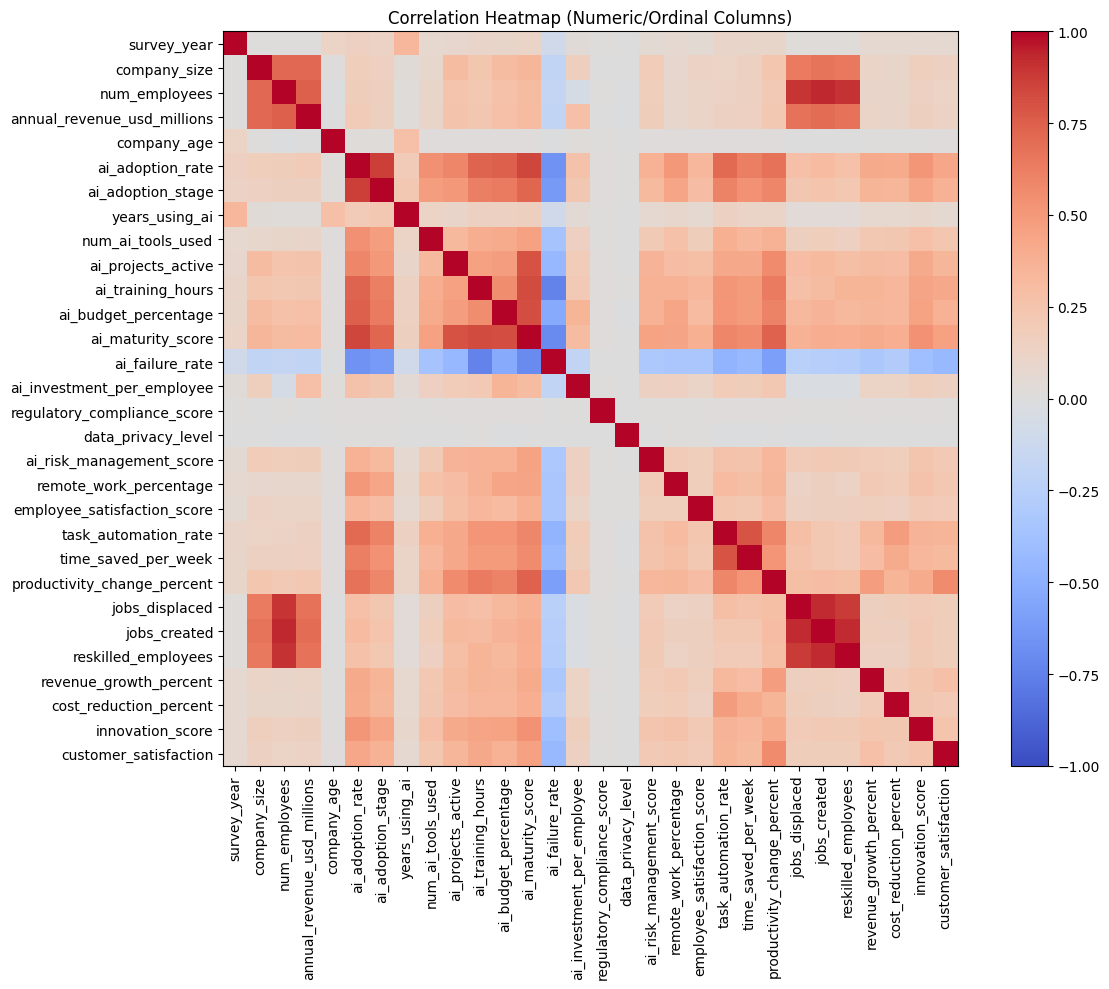

In [6]:
df[NUMERIC_ORDINAL_COLS].corr()
corr_matrix = df[NUMERIC_ORDINAL_COLS].corr()

plt.figure(figsize=(14, 10))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heatmap (Numeric/Ordinal Columns)")
plt.tight_layout()
plt.show()

### Histogram Analysis

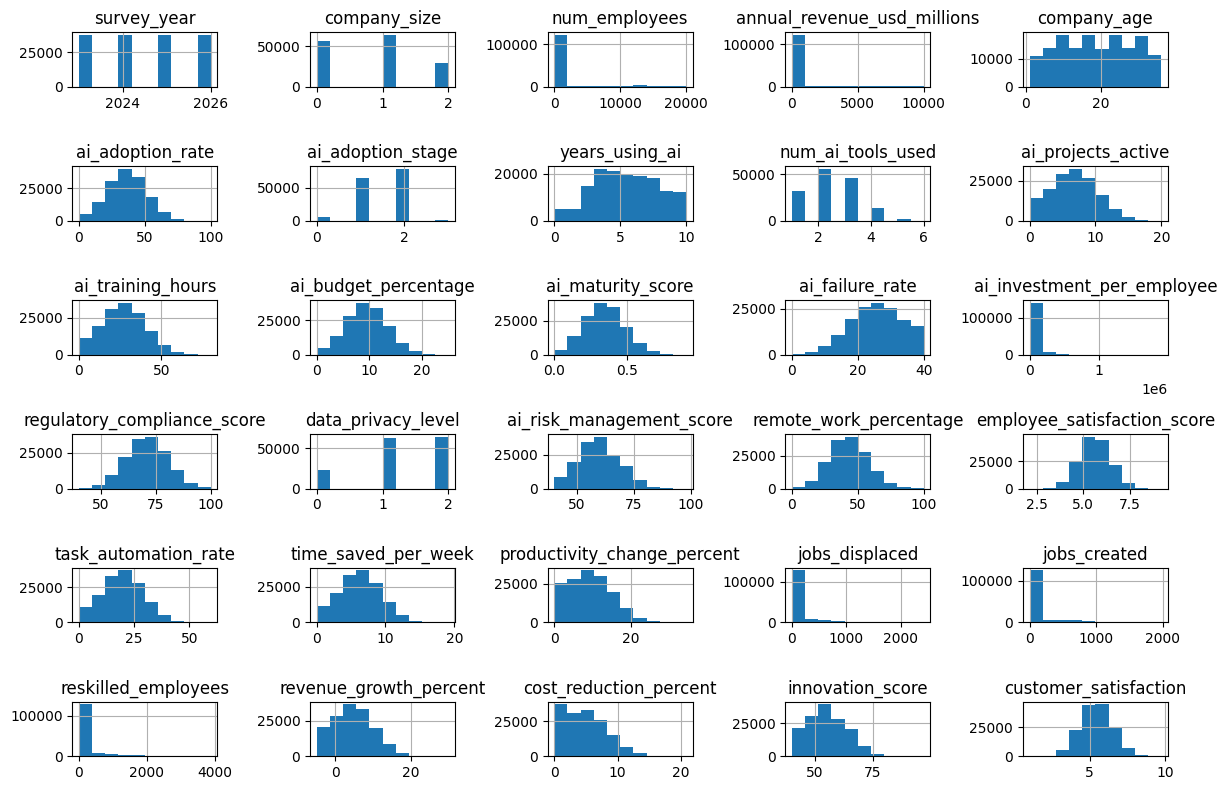

In [7]:
df[NUMERIC_ORDINAL_COLS].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

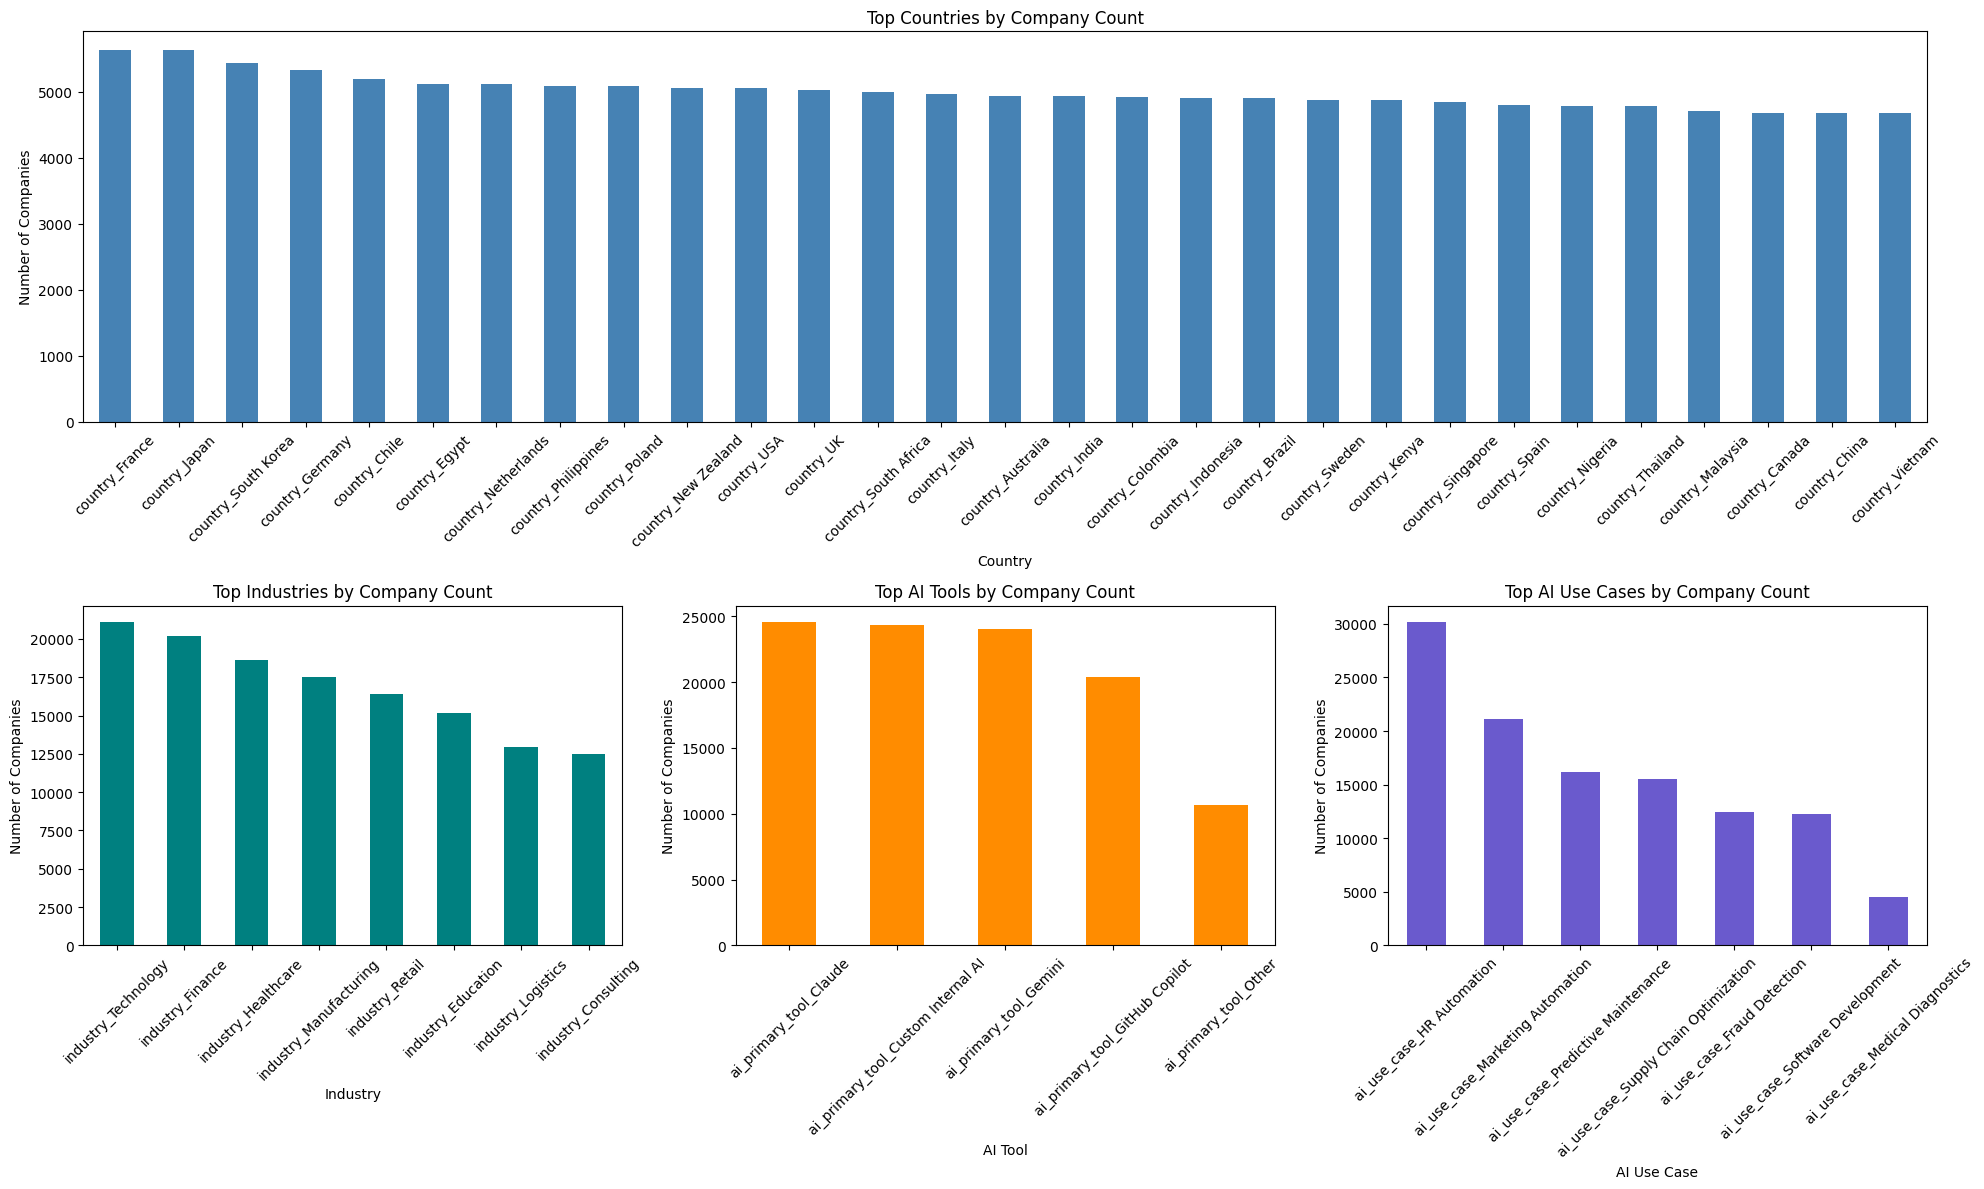

In [8]:
COUNTRY_COLS = [col for col in df.columns if col.startswith("country_")]
INDUSTRY_COLS = [col for col in df.columns if col.startswith("industry_")]
TOOL_COLS = [col for col in df.columns if col.startswith("ai_primary_tool_")]
USECASE_COLS = [col for col in df.columns if col.startswith("ai_use_case_")]

country_counts = df[COUNTRY_COLS].sum().sort_values(ascending=False)
industry_counts = df[INDUSTRY_COLS].sum().sort_values(ascending=False)
tool_counts = df[TOOL_COLS].sum().sort_values(ascending=False)
usecase_counts = df[USECASE_COLS].sum().sort_values(ascending=False)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, height_ratios=[1.15, 1])

ax_top = fig.add_subplot(gs[0, :])
country_counts.plot(kind="bar", ax=ax_top, color="steelblue")
ax_top.set_title("Top Countries by Company Count")
ax_top.set_xlabel("Country")
ax_top.set_ylabel("Number of Companies")
ax_top.tick_params(axis="x", rotation=45)

ax1 = fig.add_subplot(gs[1, 0])
industry_counts.plot(kind="bar", ax=ax1, color="teal")
ax1.set_title("Top Industries by Company Count")
ax1.set_xlabel("Industry")
ax1.set_ylabel("Number of Companies")
ax1.tick_params(axis="x", rotation=45)

ax2 = fig.add_subplot(gs[1, 1])
tool_counts.plot(kind="bar", ax=ax2, color="darkorange")
ax2.set_title("Top AI Tools by Company Count")
ax2.set_xlabel("AI Tool")
ax2.set_ylabel("Number of Companies")
ax2.tick_params(axis="x", rotation=45)

ax3 = fig.add_subplot(gs[1, 2])
usecase_counts.plot(kind="bar", ax=ax3, color="slateblue")
ax3.set_title("Top AI Use Cases by Company Count")
ax3.set_xlabel("AI Use Case")
ax3.set_ylabel("Number of Companies")
ax3.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [9]:
len(ONEHOT_COLS), len(CYCLIC_COLS), len(BINARY_COLS), len(NUMERIC_ORDINAL_COLS)

(55, 2, 1, 30)

In [10]:
NUMERIC_ORDINAL_COLS

['survey_year',
 'company_size',
 'num_employees',
 'annual_revenue_usd_millions',
 'company_age',
 'ai_adoption_rate',
 'ai_adoption_stage',
 'years_using_ai',
 'num_ai_tools_used',
 'ai_projects_active',
 'ai_training_hours',
 'ai_budget_percentage',
 'ai_maturity_score',
 'ai_failure_rate',
 'ai_investment_per_employee',
 'regulatory_compliance_score',
 'data_privacy_level',
 'ai_risk_management_score',
 'remote_work_percentage',
 'employee_satisfaction_score',
 'task_automation_rate',
 'time_saved_per_week',
 'productivity_change_percent',
 'jobs_displaced',
 'jobs_created',
 'reskilled_employees',
 'revenue_growth_percent',
 'cost_reduction_percent',
 'innovation_score',
 'customer_satisfaction']